In [1]:
import json
import os

# Conteúdo dos metadados
meta_hist = {
    "nome": "olympics_historico",
    "fonte": "Kaggle / Historical Data",
    "descricao": "Dados históricos de medalhas (1896-2022).",
    "campos": ["year", "edition", "country", "gold", "silver", "bronze", "total"],
    "data_coleta": "2026-04-01"
}

meta_paris = {
    "nome": "olympics_paris2024",
    "fonte": "Paris 2024 Official",
    "descricao": "Resultados da edição de Paris 2024.",
    "campos": ["country_code", "country", "Gold Medal", "Silver Medal", "Bronze Medal", "Total"],
    "data_coleta": "2026-04-01"
}

# Salvar os arquivos na pasta raw
with open('raw/olympics_historico.json', 'w', encoding='utf-8') as f:
    json.dump(meta_hist, f, indent=4, ensure_ascii=False)

with open('raw/olympics_paris2024.json', 'w', encoding='utf-8') as f:
    json.dump(meta_paris, f, indent=4, ensure_ascii=False)

print("Metadados criados na pasta RAW!")

✅ Metadados criados na pasta RAW!


Pasta "Bronze"

Convertendo arquivos para .parquet

In [4]:
import pandas as pd

# Ler os brutos
df_hist_raw = pd.read_csv('raw/olympics_historico.csv')
df_paris_raw = pd.read_csv('raw/olympics_paris2024.csv')

# Salvar como Parquet na Bronze
df_hist_raw.to_parquet('bronze/olympics_historico.parquet', index=False)
df_paris_raw.to_parquet('bronze/olympics_paris2024.parquet', index=False)

print("Arquivos convertidos para .parquet")

Arquivos convertidos para .parquet


Tratamento de dados - medalhas

In [5]:
import pandas as pd
import json

# 1. Carregar os Parquets da Bronze (que foram espelhados da Raw)
df_hist = pd.read_parquet('bronze/olympics_historico.parquet')
df_2024 = pd.read_parquet('bronze/olympics_paris2024.parquet')

# 2. Tratamento do Dataset de Paris 2024
df_2024_clean = df_2024.copy()

# Remove coluna 'country' original se ela existir (para usar a 'country_long')
if 'country' in df_2024_clean.columns:
    df_2024_clean = df_2024_clean.drop(columns=['country'])

# Renomeação para o padrão do histórico
df_2024_clean = df_2024_clean.rename(columns={
    'country_code': 'country_noc',
    'country_long': 'country',
    'Gold Medal': 'gold',
    'Silver Medal': 'silver',
    'Bronze Medal': 'bronze',
    'Total': 'total'
})

# Adicionando metadados da edição de 2024
df_2024_clean['year'] = 2024
df_2024_clean['edition'] = '2024 Summer Olympics'
df_2024_clean['edition_id'] = 60 

# Padronizando a ordem das colunas para ambos os DataFrames
colunas_finais = ['year', 'edition', 'edition_id', 'country', 'country_noc', 'gold', 'silver', 'bronze', 'total']

df_2024_final = df_2024_clean.reindex(columns=colunas_finais)
df_hist_final = df_hist.reindex(columns=colunas_finais)

# 3. Concatenar Histórico + 2024
df_bronze_medalhas = pd.concat([df_hist_final, df_2024_final], ignore_index=True)

# Garantir que as medalhas sejam números inteiros (evita .0 no JSON)
medal_cols = ['gold', 'silver', 'bronze', 'total']
df_bronze_medalhas[medal_cols] = df_bronze_medalhas[medal_cols].fillna(0).astype(int)

# 4. Salvamento dos arquivos de dados

# Arquivo Parquet (Exigência técnica)
df_bronze_medalhas.to_parquet('bronze/medalhas_1896_2024.parquet', index=False)

# Arquivo JSON de Dados (Formato de lista de objetos que você solicitou)
df_bronze_medalhas.to_json(
    'bronze/medalhas_1896_2024.json', 
    orient='records', 
    indent=4, 
    force_ascii=False
)

# 5. Geração do JSON de metadados
metadata_bronze = {
    "nome_do_dataset": "medalhas_1896_2024",
    "fonte": "Integração olympics_historico + olympics_paris2024",
    "descricao": "Dataset integrado contendo todo o histórico de medalhas até Paris 2024.",
    "campos_principais": colunas_finais,
    "data_de_processamento": "2026-04-02",
    "formato_armazenamento": "Parquet e JSON",
    "observacoes": "Dados padronizados, medalhas convertidas para int e concatenadas para análise final."
}

with open('bronze/metadata_medalhas_1896_2024.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_bronze, f, indent=4, ensure_ascii=False)

print("Arquivo Parquet, JSON de registros e Metadados gerados na Bronze.")

Arquivos Parquet, JSON de dados e Metadados gerados na Bronze.


Tratamento de dados - Modalidades

In [6]:
import pandas as pd
import json
import os

# 1. Conversão inicial
# Lendo os arquivos originais da pasta RAW
df_events_hist_raw = pd.read_csv('raw/events_result.csv', low_memory=False)
df_events_2024_raw = pd.read_csv('raw/events.csv')

# Salvando os Parquets individuais na Bronze (Espelhamento técnico)
df_events_hist_raw.to_parquet('bronze/events_result.parquet', index=False)
df_events_2024_raw.to_parquet('bronze/events_2024.parquet', index=False)


# 2. Tratamento
df_events_hist = pd.read_parquet('bronze/events_result.parquet')
df_events_2024 = pd.read_parquet('bronze/events_2024.parquet')

# Tratamento do histórico (1896-2022)
df_mod_hist = df_events_hist[['edition', 'sport']].drop_duplicates().copy()
# Extrair o ano da edição (Ex: "1896 Summer Olympics" -> 1896)
df_mod_hist['year'] = df_mod_hist['edition'].astype(str).str.split().str[0]

# Tratamento de 2024
# Criando um DataFrame a partir dos esportes únicos de 2024
esportes_2024 = df_events_2024['sport'].unique()
df_mod_2024 = pd.DataFrame({
    'sport': esportes_2024,
    'edition': '2024 Summer Olympics',
    'year': '2024'
})

# 3. Concatenação
colunas_ordenadas = ['year', 'edition', 'sport']
df_mod_hist = df_mod_hist[colunas_ordenadas]
df_mod_2024 = df_mod_2024[colunas_ordenadas]

# União Final
df_modalidades_bronze = pd.concat([df_mod_hist, df_mod_2024], ignore_index=True)

# Limpeza: Converter ano para numérico e remover possíveis nulos
df_modalidades_bronze['year'] = pd.to_numeric(df_modalidades_bronze['year'], errors='coerce')
df_modalidades_bronze = df_modalidades_bronze.dropna(subset=['year']).sort_values('year')
df_modalidades_bronze['year'] = df_modalidades_bronze['year'].astype(int)

# 4. Persistência de dados na bronze
# Arquivo Parquet (Exigência do projeto)
df_modalidades_bronze.to_parquet('bronze/modalidades_1896_2024.parquet', index=False)

# Arquivo JSON de Registros
df_modalidades_bronze.to_json(
    'bronze/modalidades_1896_2024.json', 
    orient='records', 
    indent=4, 
    force_ascii=False
)

# 5. Geração do JSON de metadados
metadata_modalidades = {
    "nome_do_dataset": "modalidades_1896_2024",
    "fonte": "Integração events_result + events (Paris 2024)",
    "descricao": "Lista de modalidades esportivas presentes em cada edição das Olimpíadas.",
    "campos_principais": colunas_ordenadas,
    "data_de_processamento": "2026-04-02",
    "formato_armazenamento": "Parquet e JSON",
    "observacoes": "Dados extraídos e normalizados a partir dos resultados de eventos."
}

with open('bronze/metadata_modalidades_1896_2024.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_modalidades, f, indent=4, ensure_ascii=False)

print("Modalidades: Parquet, JSON de dados e Metadados gerados com sucesso na Bronze!")
print(df_modalidades_bronze.head())

Modalidades: Parquet, JSON de dados e Metadados gerados com sucesso na Bronze!
     year               edition          sport
603  1896  1896 Summer Olympics        Fencing
546  1896  1896 Summer Olympics      Athletics
459  1896  1896 Summer Olympics         Tennis
498  1896  1896 Summer Olympics       Shooting
294  1896  1896 Summer Olympics  Weightlifting


Tratamento de dados - Atletas

In [7]:
import pandas as pd
import json

# 1. Lendo os arquivos da RAW
df_atleta_hist_raw = pd.read_csv('raw/athletes1896_2022.csv')
df_atleta_2024_raw = pd.read_csv('raw/athletes2024.csv')
df_results_hist_raw = pd.read_csv('raw/events_result.csv', low_memory=False)

# Salvando Parquets de espelhamento na Bronze
df_atleta_hist_raw.to_parquet('bronze/athletes_hist.parquet', index=False)
df_atleta_2024_raw.to_parquet('bronze/athletes_2024.parquet', index=False)
df_results_hist_raw.to_parquet('bronze/events_result.parquet', index=False)

# 2. Processamento
df_atleta_hist = pd.read_parquet('bronze/athletes_hist.parquet')
df_atleta_2024 = pd.read_parquet('bronze/athletes_2024.parquet')
df_results_hist = pd.read_parquet('bronze/events_result.parquet')

# Processar Histórico
df_hist_merge = pd.merge(
    df_results_hist, 
    df_atleta_hist[['athlete_id', 'sex']], 
    on='athlete_id', 
    how='left'
)

# Contar atletas únicos por edição e sexo
df_sexo_hist = df_hist_merge.groupby(['edition', 'sex'])['athlete_id'].nunique().reset_index(name='count')
df_sexo_hist['year'] = df_sexo_hist['edition'].astype(str).str.split().str[0]

# Processar Paris 2024
# Se a coluna for 'gender', renomeamos para 'sex' para bater com o histórico
if 'gender' in df_atleta_2024.columns:
    df_atleta_2024 = df_atleta_2024.rename(columns={'gender': 'sex'})

df_sexo_2024 = df_atleta_2024.groupby('sex').size().reset_index(name='count')
df_sexo_2024['edition'] = '2024 Summer Olympics'
df_sexo_2024['year'] = '2024'


# 3. Concatenar
df_bronze_sexo = pd.concat([df_sexo_hist, df_sexo_2024], ignore_index=True)

# Limpeza: Garantir ano como inteiro e ordenar
df_bronze_sexo['year'] = pd.to_numeric(df_bronze_sexo['year'], errors='coerce')
df_bronze_sexo = df_bronze_sexo.dropna(subset=['year']).sort_values(['year', 'sex'])
df_bronze_sexo['year'] = df_bronze_sexo['year'].astype(int)

# Reordenar colunas
colunas_sexo = ['year', 'edition', 'sex', 'count']
df_bronze_sexo = df_bronze_sexo[colunas_sexo]


# 4. Persistência na Bronze
# Arquivo Parquet (Requisito)
df_bronze_sexo.to_parquet('bronze/atletas_por_sexo.parquet', index=False)

# Arquivo JSON de Registros (Seu formato preferido)
df_bronze_sexo.to_json(
    'bronze/atletas_por_sexo.json', 
    orient='records', 
    indent=4, 
    force_ascii=False
)

# 5. Geração do JSON de metadados
metadata_sexo = {
    "nome_do_dataset": "atletas_por_sexo",
    "fonte": "Cruzamento de biografia de atletas com resultados de eventos (1896-2024)",
    "descricao": "Contagem de atletas únicos participantes em cada edição, segregados por sexo.",
    "campos_principais": colunas_sexo,
    "data_de_processamento": "2026-04-02",
    "formato_armazenamento": "Parquet e JSON",
    "observacoes": "Utilizado nunique() para evitar contagem duplicada de atletas que competiram em mais de um evento na mesma edição."
}

with open('bronze/metadata_atletas_por_sexo.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_sexo, f, indent=4, ensure_ascii=False)

print("Atletas por Sexo: Parquet, JSON de dados e Metadados gerados com sucesso!")

Atletas por Sexo: Parquet, JSON de dados e Metadados gerados com sucesso!


Pasta "GOLD"

Análise "Medalhas"

In [8]:
import pandas as pd
import json
import os

# 1. Ler o dado integrado da Bronze
df_bronze = pd.read_parquet('bronze/medalhas_1896_2024.parquet')

# 2. Gerar o Summary (Ranking Histórico por País)
# Agrupamos por país e somamos as medalhas
medalhas_summary = df_bronze.groupby(['country', 'country_noc']).agg({
    'gold': 'sum',
    'silver': 'sum',
    'bronze': 'sum',
    'total': 'sum'
}).reset_index()

# Ordenar pelo padrão olímpico (Ouro > Prata > Bronze)
medalhas_summary = medalhas_summary.sort_values(by=['gold', 'silver', 'bronze'], ascending=False)

# 3. Salvar os Dados na Gold
# Salvando em Parquet (conforme solicitado pelo professor)
medalhas_summary.to_parquet('gold/analise_medalhas/medalhas_summary.parquet', index=False)

# 4. Gerar o Metadados JSON da Gold
metadata_gold_medalhas = {
    "nome_do_dataset": "medalhas_summary",
    "camada": "Gold",
    "descricao": "Ranking histórico acumulado de medalhas por país (1896-2024).",
    "campos_principais": ["country", "gold", "silver", "bronze", "total"],
    "criterio_ordenacao": "Padrão Olímpico (Ouro, Prata, Bronze)",
    "data_criacao": "2026-04-02"
}

with open('gold/analise_medalhas/metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_gold_medalhas, f, indent=4, ensure_ascii=False)

print("Gold: Resumo de medalhas e metadados gerados!")

Gold: Resumo de medalhas e metadados gerados!


Gráfico: Top 10 países 

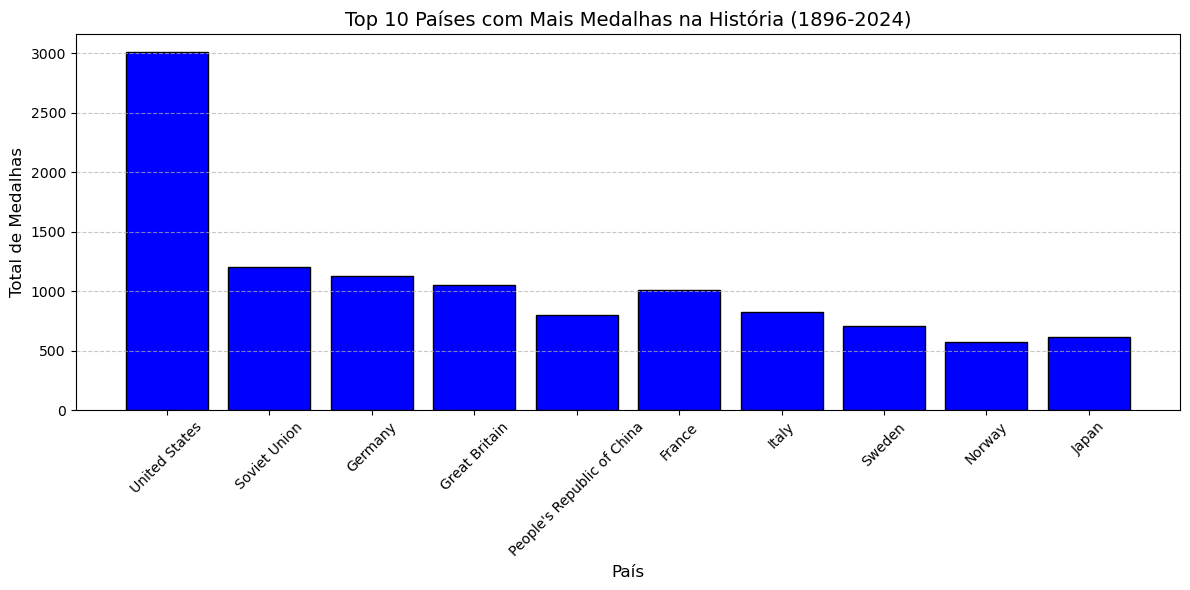

Gráfico gerado e salvo em gold/analise_medalhas/medalhas_plot.png


In [10]:
import matplotlib.pyplot as plt

# Pegar os 10 primeiros países
top_10 = medalhas_summary.head(10)

# Criar o gráfico
plt.figure(figsize=(12, 6))
plt.bar(top_10['country'], top_10['total'], color='blue', edgecolor='black')

plt.title('Top 10 Países com Mais Medalhas na História (1896-2024)', fontsize=14)
plt.xlabel('País', fontsize=12)
plt.ylabel('Total de Medalhas', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvar a imagem na pasta Gold
plt.tight_layout()
plt.savefig('gold/analise_medalhas/medalhas_plot.png')
plt.show()

print("Gráfico gerado e salvo em gold/analise_medalhas/medalhas_plot.png")

Análise "Modalidades"

In [11]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt

# 1. Ler o dado integrado da Bronze
df_mod_bronze = pd.read_parquet('bronze/modalidades_1896_2024.parquet')

# 2. Gerar o Summary (Contagem de esportes por ano)
modalidades_summary = df_mod_bronze.groupby(['year', 'edition'])['sport'].nunique().reset_index(name='total_esportes')

# Ordenar por ano
modalidades_summary = modalidades_summary.sort_values('year')

# 3. Salvar os Dados na Gold (Parquet)
modalidades_summary.to_parquet('gold/analise_modalidades/modalidades_summary.parquet', index=False)

# 4. Gerar o Metadados JSON
metadata_gold_mod = {
    "nome_do_dataset": "modalidades_summary",
    "camada": "Gold",
    "descricao": "Contagem histórica do número de modalidades esportivas por edição das Olimpíadas.",
    "campos_principais": ["year", "edition", "total_esportes"],
    "data_criacao": "2026-04-02",
    "observacoes": "Análise focada na expansão do programa olímpico ao longo dos anos."
}

with open('gold/analise_modalidades/metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_gold_mod, f, indent=4, ensure_ascii=False)

print("Gold: Resumo de modalidades e metadados gerados!")

Gold: Resumo de modalidades e metadados gerados!


Gráfico de evolução

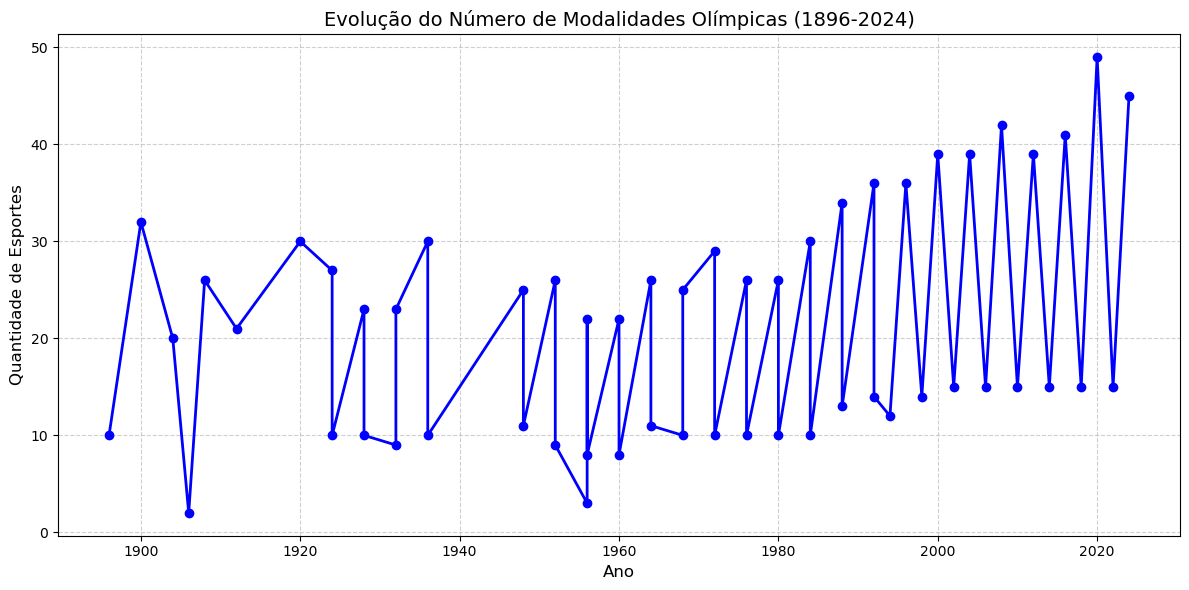

Gráfico gerado e salvo em gold/analise_modalidades/modalidades_plot.png


In [12]:
# Criar o gráfico de evolução
plt.figure(figsize=(12, 6))

# Gráfico de linha com pontos para marcar cada edição
plt.plot(modalidades_summary['year'], modalidades_summary['total_esportes'], 
         marker='o', linestyle='-', color='blue', linewidth=2, markersize=6)

plt.title('Evolução do Número de Modalidades Olímpicas (1896-2024)', fontsize=14)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Quantidade de Esportes', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Salvar a imagem
plt.tight_layout()
plt.savefig('gold/analise_modalidades/modalidades_plot.png')
plt.show()

print("Gráfico gerado e salvo em gold/analise_modalidades/modalidades_plot.png")

Análise "Gênero"

In [14]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt

# 1. Ler o dado integrado da Bronze
df_sexo_bronze = pd.read_parquet('bronze/atletas_por_sexo.parquet')

# 2. Gerar o Summary (Pivotar para ter colunas M e F por ano)
genero_summary = df_sexo_bronze.pivot(index=['year', 'edition'], columns='sex', values='count').reset_index()

# Renomear colunas para ficar mais claro (M -> Masculino, F -> Feminino)
genero_summary = genero_summary.rename(columns={'Male': 'Masculino', 'Female': 'Feminino'})

# Preencher possíveis anos sem mulheres (edições muito antigas) com 0
genero_summary['Feminino'] = genero_summary['Feminino'].fillna(0).astype(int)
genero_summary['Masculino'] = genero_summary['Masculino'].fillna(0).astype(int)

# 3. Salvar os Dados na Gold (Parquet)
genero_summary.to_parquet('gold/analise_genero/genero_summary.parquet', index=False)

# 4. Gerar o Metadados JSON
metadata_gold_gen = {
    "nome_do_dataset": "genero_summary",
    "camada": "Gold",
    "descricao": "Evolução da participação de atletas homens e mulheres por edição.",
    "campos_principais": ["year", "edition", "Masculino", "Feminino"],
    "data_criacao": "2026-04-02",
    "observacoes": "Análise da disparidade histórica de gênero nas Olimpíadas."
}

with open('gold/analise_genero/metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_gold_gen, f, indent=4, ensure_ascii=False)

print("Gold: Análise de gênero e metadados gerados!")

Gold: Análise de gênero e metadados gerados!


Gráfico de comparação

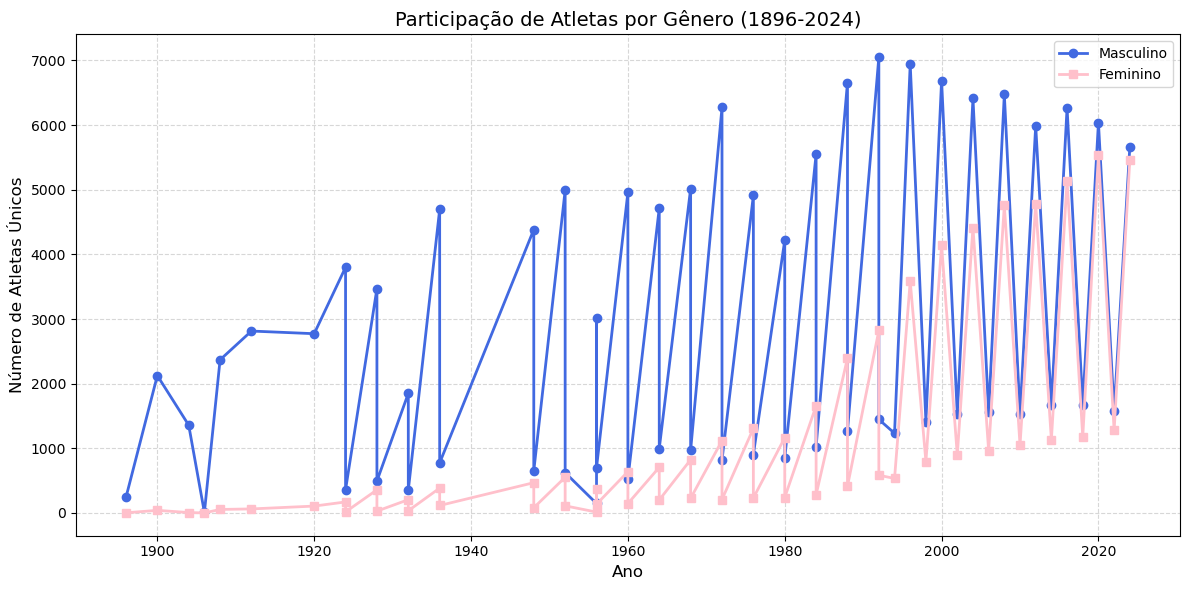

Gráfico de gênero salvo com sucesso!


In [17]:
# Criar o gráfico de comparação
plt.figure(figsize=(12, 6))

# Linha dos Homens (Azul Royal)
plt.plot(genero_summary['year'], genero_summary['Masculino'], 
         label='Masculino', color='royalblue', marker='o', linewidth=2)

# Linha das Mulheres (Azul Celeste/Cyan para manter sua preferência de azul)
plt.plot(genero_summary['year'], genero_summary['Feminino'], 
         label='Feminino', color='pink', marker='s', linewidth=2)

plt.title('Participação de Atletas por Gênero (1896-2024)', fontsize=14)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Número de Atletas Únicos', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Salvar a imagem
plt.tight_layout()
plt.savefig('gold/analise_genero/genero_plot.png')
plt.show()

print("Gráfico de gênero salvo com sucesso!")